In [9]:
import json

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from lcdb.db._results import ResultSet
from lcdb.analysis.views._util import get_cli_test_command

In [10]:
rs = ResultSet()

for k in [
    "lcdb.workflow.sklearn.KNNWorkflow",
    #"lcdb.workflow.sklearn.LibLinearWorkflow",
    #"lcdb.workflow.sklearn.LibSVMWorkflow",
    #"lcdb.workflow.sklearn.TreesEnsembleWorkflow",
    #"lcdb.workflow.xgboost.XGBoostWorkflow"
]:
    _rs = ResultSet()
    _rs.load(f"data/{k}.jsonl")
    _rs.reduce(lambda row: "results" not in row or row["results"] is None)
    #_rs.drop_rows_with_build_issues()
    rs.extend(_rs)
#dfs[k]["runtimes"] = dfs[k]["runtimes"].apply(lambda r: json.loads(r) if type(r) == str else None)
print(rs.num_rows)

4131


In [11]:
for openmlid, rs_dataset in rs.group_by_dataset():
    print(openmlid, rs_dataset.num_rows)
    #print(get_cli_test_command(row))

12 8
1111 100
1169 100
1457 100
1461 100
1468 100
1486 100
1515 100
1590 100
1596 100
4134 100
4135 100
4541 100
23517 100
40668 100
40670 5
40685 100
40978 12
40996 100
41027 100
41138 100
41142 5
41143 1
41144 100
41145 100
41147 100
41150 100
41157 100
41158 100
41159 100
41161 100
41162 100
41163 100
41164 100
41165 100
41166 100
41167 100
41168 100
41169 100
42732 100
42733 100
42734 100
42742 100
42746 100
42769 100
43072 100


In [ ]:
for openmlid, rs_for_dataset in rs.group_by_dataset():
    print(openmlid, rs_for_dataset.num_rows)
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (config, rs_for_dataset_config) in enumerate(rs_for_dataset.group_by_config()):
        print(rs_for_dataset_config.num_rows)
        lc = rs_for_dataset_config.get_learning_curve()
        if lc is not None and lc != "None":
            ax.plot(lc.anchors_size, lc.values[0, 1, 0, 0, 0])
            ax.set_xticks(lc.anchors_size)
            ax.set_xticklabels(lc.anchors_size)
            if i > 10:
                break
    ax.set_title(f"Learning curves for dataset {openmlid}")
    plt.show()

In [8]:
rs.num_rows

6946

In [ ]:
#for row in rs:
    #if "256" in row["build_issues"]:
     #   print(get_cli_test_command(row))
      #  print(row["build_issues"]["256"])
    

lcdb test -i 3 -w lcdb.workflow.sklearn.KNNWorkflow --parameters='{"metric": "minkowski", "n_neighbors": 6, "pp@cat_encoder": "onehot", "pp@decomposition": "kernel_pca", "pp@featureselector": "selectp", "pp@scaler": "minmax", "weights": "uniform", "p": 8.0, "pp@feature_map_size": 1.0, "pp@featuregen": "none", "pp@kernel_mapper_kernel": "sigmoid", "pp@projection_features": 0.435814824533, "pp@selectp_percentile": 27.0, "pp@std_with_std": true, "pp@kernel_mapper_coef0": 31.0629218291306, "pp@kernel_mapper_degree": 5.0, "pp@kernel_mapper_gamma": 3.9870723023571, "pp@poly_degree": 2.0}' --log-level=debug --no-exception-on-unsuitable-preprocessor --suppress-json-output
"Traceback (most recent call last):
  File "/gpfs/home2/cyan/lcdb/publications/2023-neurips/lcdb/builder/_base.py", line 364, in build_curves
    self.fit_workflow_on_current_anchor()
  File "/gpfs/home2/cyan/lcdb/publications/2023-neurips/lcdb/builder/_base.py", line 447, in fit_workflow_on_current_anchor
    self.workflow.f

In [4]:
import pandas as pd
d_datasets = sorted(pd.unique(overview_debugger.df["m:openmlid"]))
d_workflows = sorted(pd.unique(overview_debugger.df["m:workflow"]))

In [5]:
import numpy as np

error_matrix = np.zeros((len(d_workflows), len(d_datasets)))

for i, workflow in enumerate(d_workflows):
    mask = (overview_debugger.df["m:workflow"] == workflow)
    for j, dataset in enumerate(d_datasets):
        df = overview_debugger.df[(overview_debugger.df["m:openmlid"] == dataset) & mask]
        error_matrix[i, j] = len(df)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sb

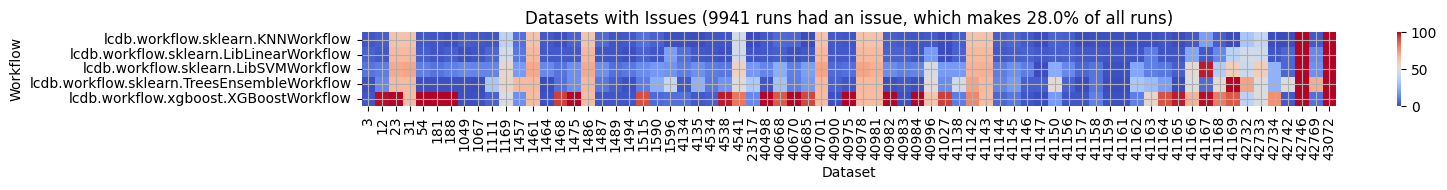

In [7]:
fig, ax = plt.subplots(figsize=(16, 2))
sb.heatmap(error_matrix, fmt='d', cmap='coolwarm', ax=ax, vmin=0, vmax=100)
issues_per_dataset = np.sum(error_matrix, axis=0)
ax.set_xticks(np.arange(len(d_datasets)) + 0.5)
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_ylabel('Workflow')
ax.set_xlabel('Dataset')
ax.set_title(f'Datasets with Issues ({int(np.sum(error_matrix))} runs had an issue, which makes {np.round(np.sum(error_matrix) / (error_matrix.shape[0] * error_matrix.shape[1]), 2)}% of all runs)')
ax.grid()
plt.tight_layout()
plt.show()

In [8]:
known_messages = [
    "timeout",
    "anticipated memory overflow",
    "cudaErrorNoDevice", # this is an error that often pops up with XGBoost
    "Found array with 0 feature(s)",
    "Found array with 1 feature(s)", # this is a problem if FeatureAgglomeration is being used, which needs at least two features
    "Cannot extract more clusters than samples",
    "array must not contain infs or NaNs",
    "There are significant negative eigenvalues"
]

In [9]:
msgs = set()
for summary in overview_debugger.df["traceback_summary"]:
    for msg in summary:
        if not any([pattern in msg["message"] for pattern in known_messages]):
            msgs.add(msg["message"])
print(f"Found {len(msgs)} distinct error messages")

Found 11 distinct error messages


In [10]:
for msg in msgs:
    print(msg)

ValueError: The number of samples must be more than the number of classes.
AssertionError: inconsistent probabilities, sums are: [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
ValueError: zero-size array to reduction operation maximum which has no identity
TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
ArpackError: ARPACK error -9: Starting vector is zero.
ValueError: The dual coefficients or intercepts are not finite. The input data may contain large values and need to be preprocessed.
ValueError: illegal value in 4th argument of internal gesdd
Traceback (most recent call last):
  File "/gpfs/home2/cyan/lcdb/publications/2023-neurips/lcdb/builder/utils.py", line 207, in terminate_on_memory_exceeded
    output = future.result()
             ^^^^^^^^^^^^^^^
  File "/home/cyan/miniconda3/envs/lcdb/lib/python3.11/concurrent/futures/_base.py", line

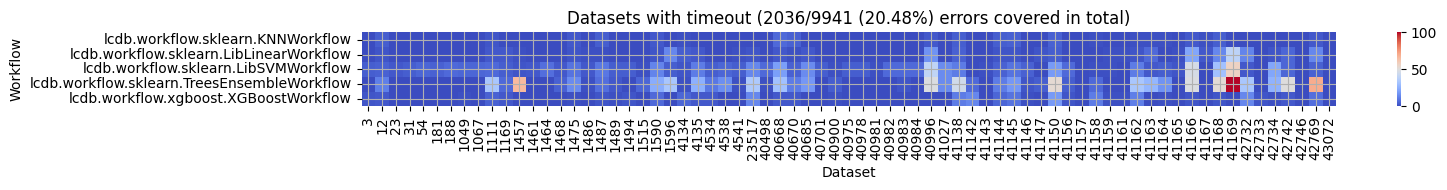

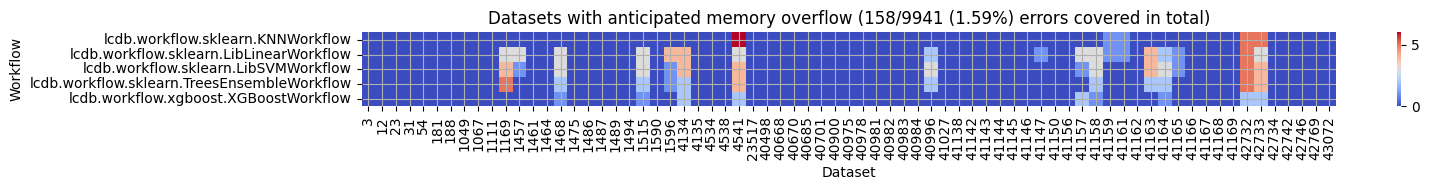

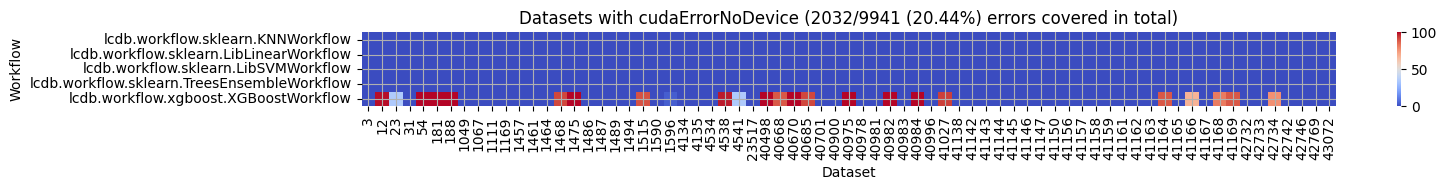

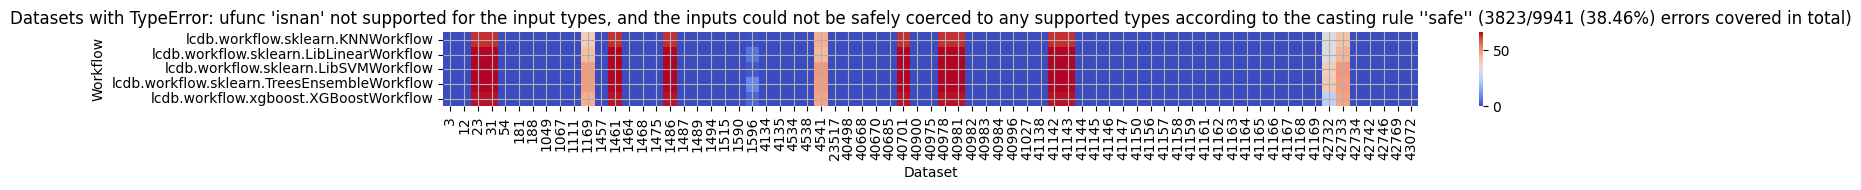

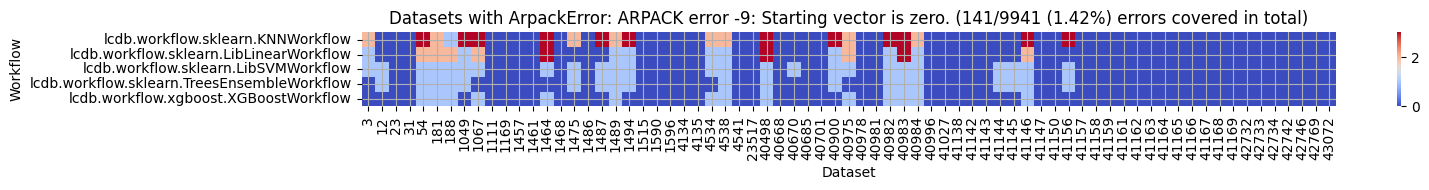

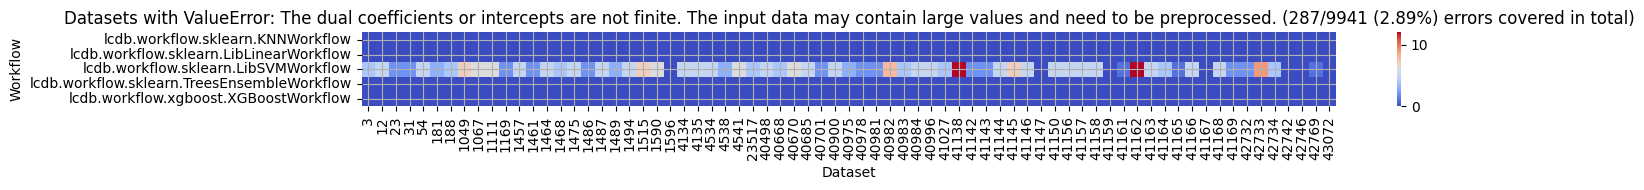

/tmp/ipykernel_316084/1027415040.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


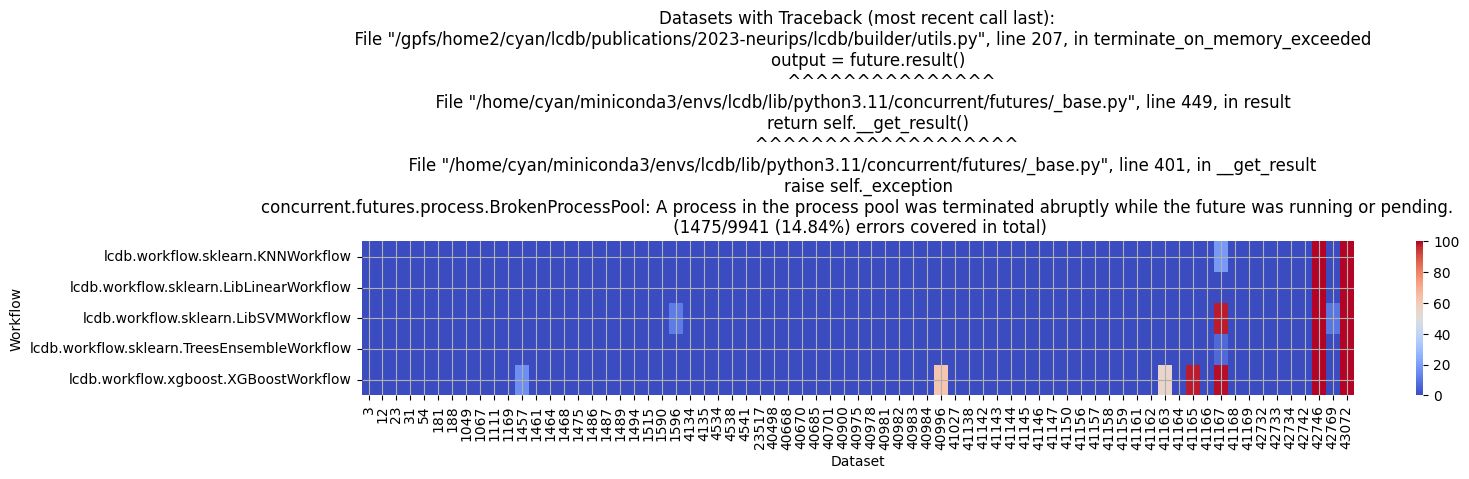

In [15]:
for pattern in list(known_messages) + list(msgs):
    error_matrix_msg = np.zeros((len(d_workflows), len(d_datasets)))

    for i, workflow in enumerate(d_workflows):
        mask = (overview_debugger.df["m:workflow"] == workflow)
        for j, dataset in enumerate(d_datasets):
            df = overview_debugger.df[(overview_debugger.df["m:openmlid"] == dataset) & mask]
            for summary in df["traceback_summary"]:
                if any([pattern in msg["message"] for msg in summary]):
                    error_matrix_msg[i, j] += 1
    
    if np.sum(error_matrix_msg) >= 50:
        fig, ax = plt.subplots(figsize=(16, 2))
        sb.heatmap(error_matrix_msg, fmt='d', cmap='coolwarm', ax=ax)#, vmin=0, vmax=100)
        ax.set_xticks(np.arange(len(d_datasets)) + 0.5)
        ax.set_xticklabels(d_datasets, rotation=90)
        ax.set_yticklabels(d_workflows, rotation=0)
        ax.set_ylabel('Workflow')
        ax.set_xlabel('Dataset')
        ax.set_title(f'Datasets with {pattern} ({int(np.sum(error_matrix_msg))}/{len(overview_debugger.df)} ({np.round(100 * np.sum(error_matrix_msg) / len(overview_debugger.df), 2)}%) errors covered in total)')
        ax.grid()
        plt.tight_layout()
        plt.show()

# Check On Which Anchor Timeouts Occurred

In [30]:
timeout_data = []
for i, workflow in enumerate(d_workflows):
    mask = (overview_debugger.df["m:workflow"] == workflow)

    for j, dataset in enumerate(d_datasets,):
        df = overview_debugger.df[(overview_debugger.df["m:openmlid"] == dataset) & mask]
        num_failed_configs += len(df)
        for summary in df["traceback_summary"]:
            matching_indices = np.where(["timeout" in msg["message"] for msg in summary])[0]
            if len(matching_indices) > 0:
                anchor = int(summary[matching_indices[0]]["location"][7:])
                timeout_data.append([workflow, dataset, anchor])
df_timeouts = pd.DataFrame(timeout_data, columns=["workflow", "openmlid", "anchor"])
df_timeouts

,workflow,openmlid,anchor
0,lcdb.workflow.sklearn.KNNWorkflow,12,1448
1,lcdb.workflow.sklearn.KNNWorkflow,12,1448
2,lcdb.workflow.sklearn.KNNWorkflow,12,1448
3,lcdb.workflow.sklearn.KNNWorkflow,12,1448
4,lcdb.workflow.sklearn.KNNWorkflow,1111,1448
...,...,...,...
2031,lcdb.workflow.xgboost.XGBoostWorkflow,42769,11585
2032,lcdb.workflow.xgboost.XGBoostWorkflow,42769,741455
2033,lcdb.workflow.xgboost.XGBoostWorkflow,42769,741455
2034,lcdb.workflow.xgboost.XGBoostWorkflow,42769,131072


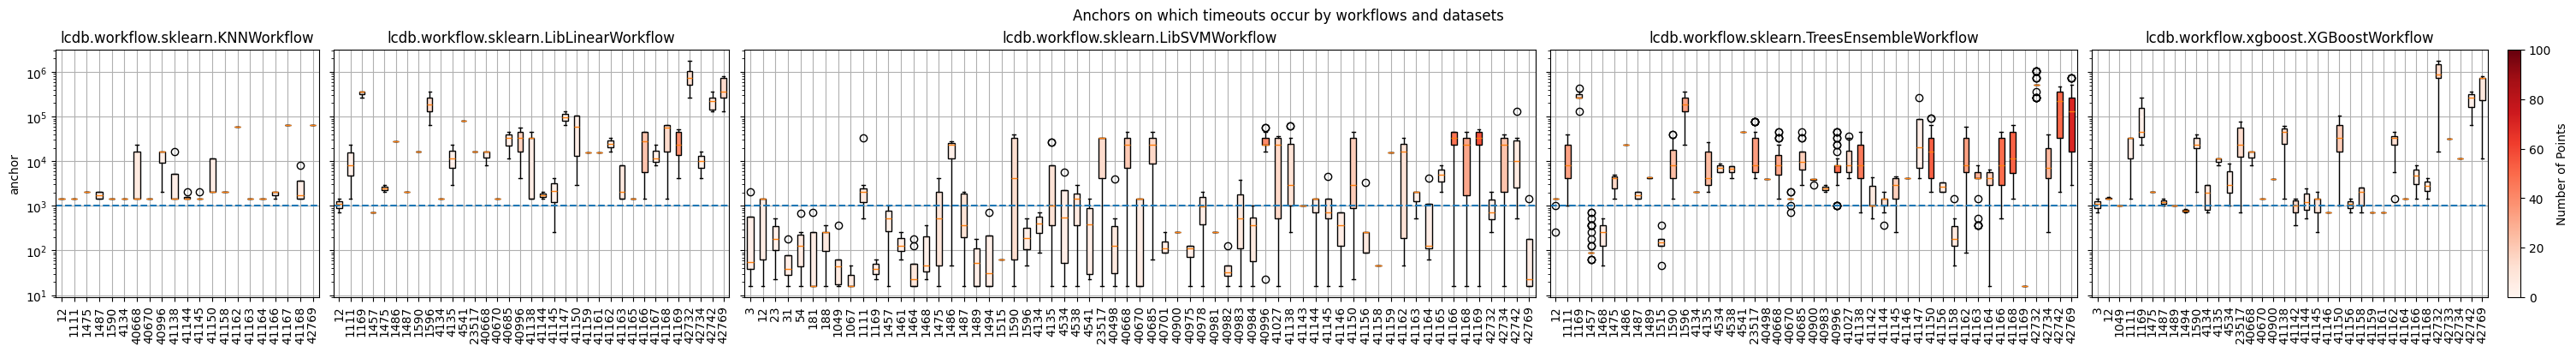

In [54]:
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, axs = plt.subplots(1, len(d_workflows), figsize=(6 * len(d_workflows), 4), sharey=True, constrained_layout=True, gridspec_kw={'width_ratios': [1, 1.5, 3, 2, 1.5]})
for i, ((workflow, df_workflow), ax) in enumerate(zip(df_timeouts.groupby("workflow"), axs)):
    datasets_for_workflow_timeout = []
    data_to_plot = []
    sizes = []
    for d, _ in df_workflow.groupby("openmlid"):
        datasets_for_workflow_timeout.append(d)
        data_to_plot.append(_["anchor"])
        sizes.append(len(_))
    box = ax.boxplot(data_to_plot, patch_artist=True)

    # adjust colors to reflect the number of items in each boxplot
    norm = mcolors.Normalize(vmin=0, vmax=100)
    cmap = matplotlib.colormaps['Reds']

    for patch, size in zip(box['boxes'], sizes):
        color = cmap(norm(size))
        patch.set_facecolor(color)

    ax.set_xticklabels(datasets_for_workflow_timeout, rotation=90)
    ax.set_yscale("log")
    if i == 0:
        ax.set_ylabel("anchor")
    ax.grid()
    ax.axhline(1000, linestyle="--")
    ax.set_title(workflow)

# Add a vertical colorbar (sidebar)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Number of Points')  # label for the sidebar
fig.suptitle("Anchors on which timeouts occur by workflows and datasets")
plt.show()

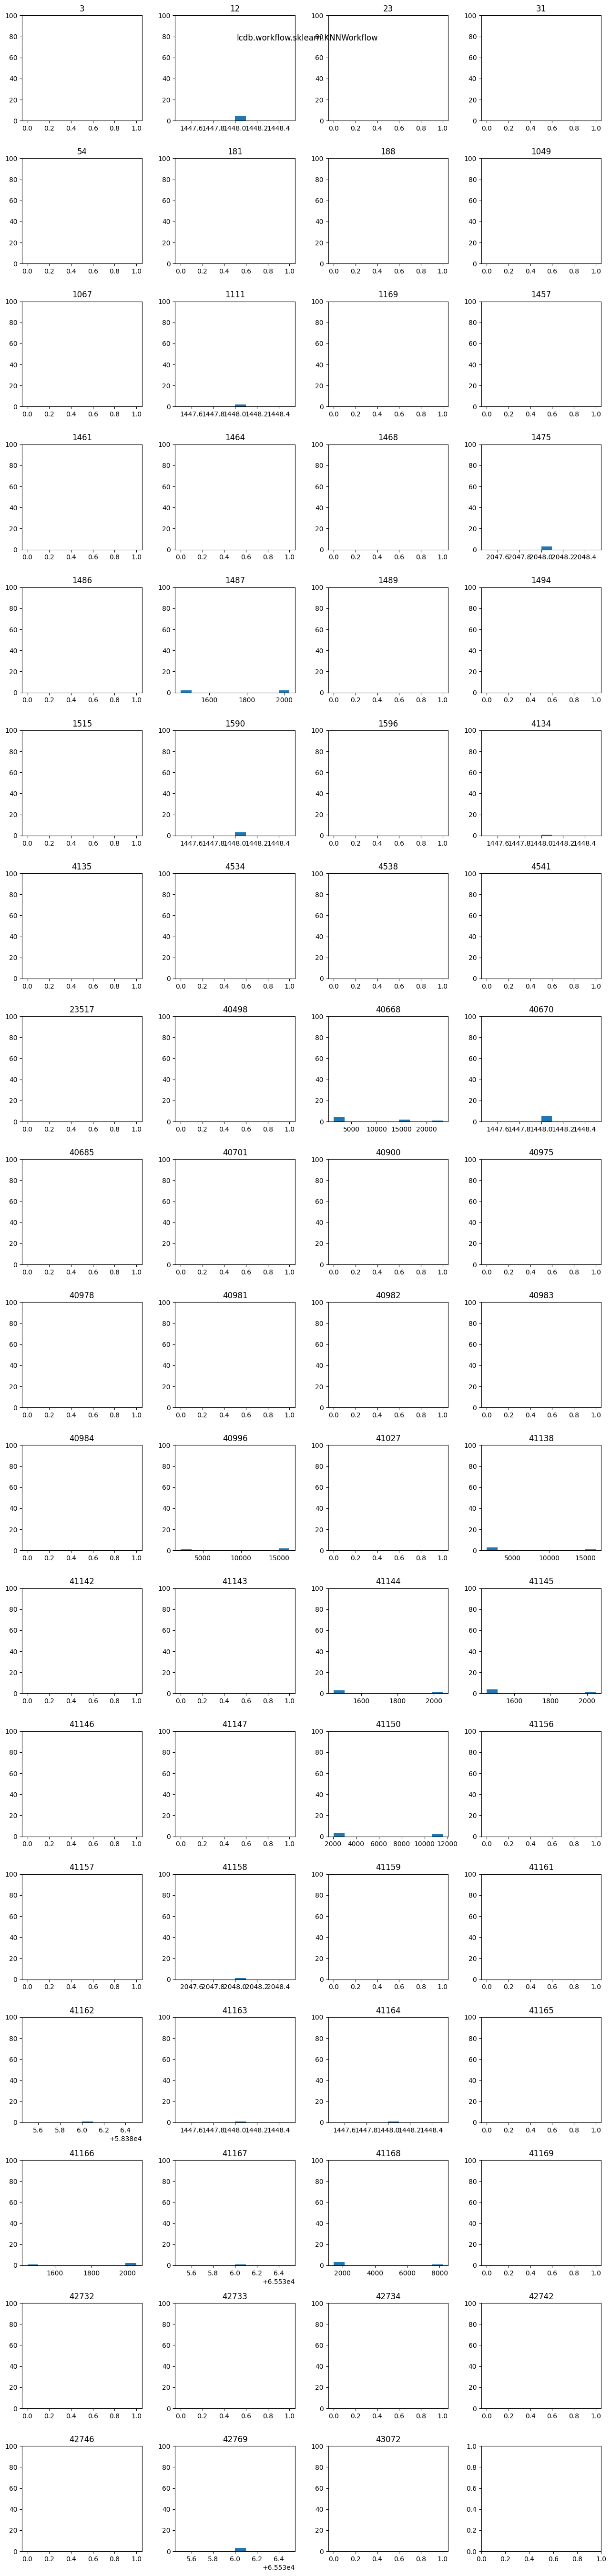

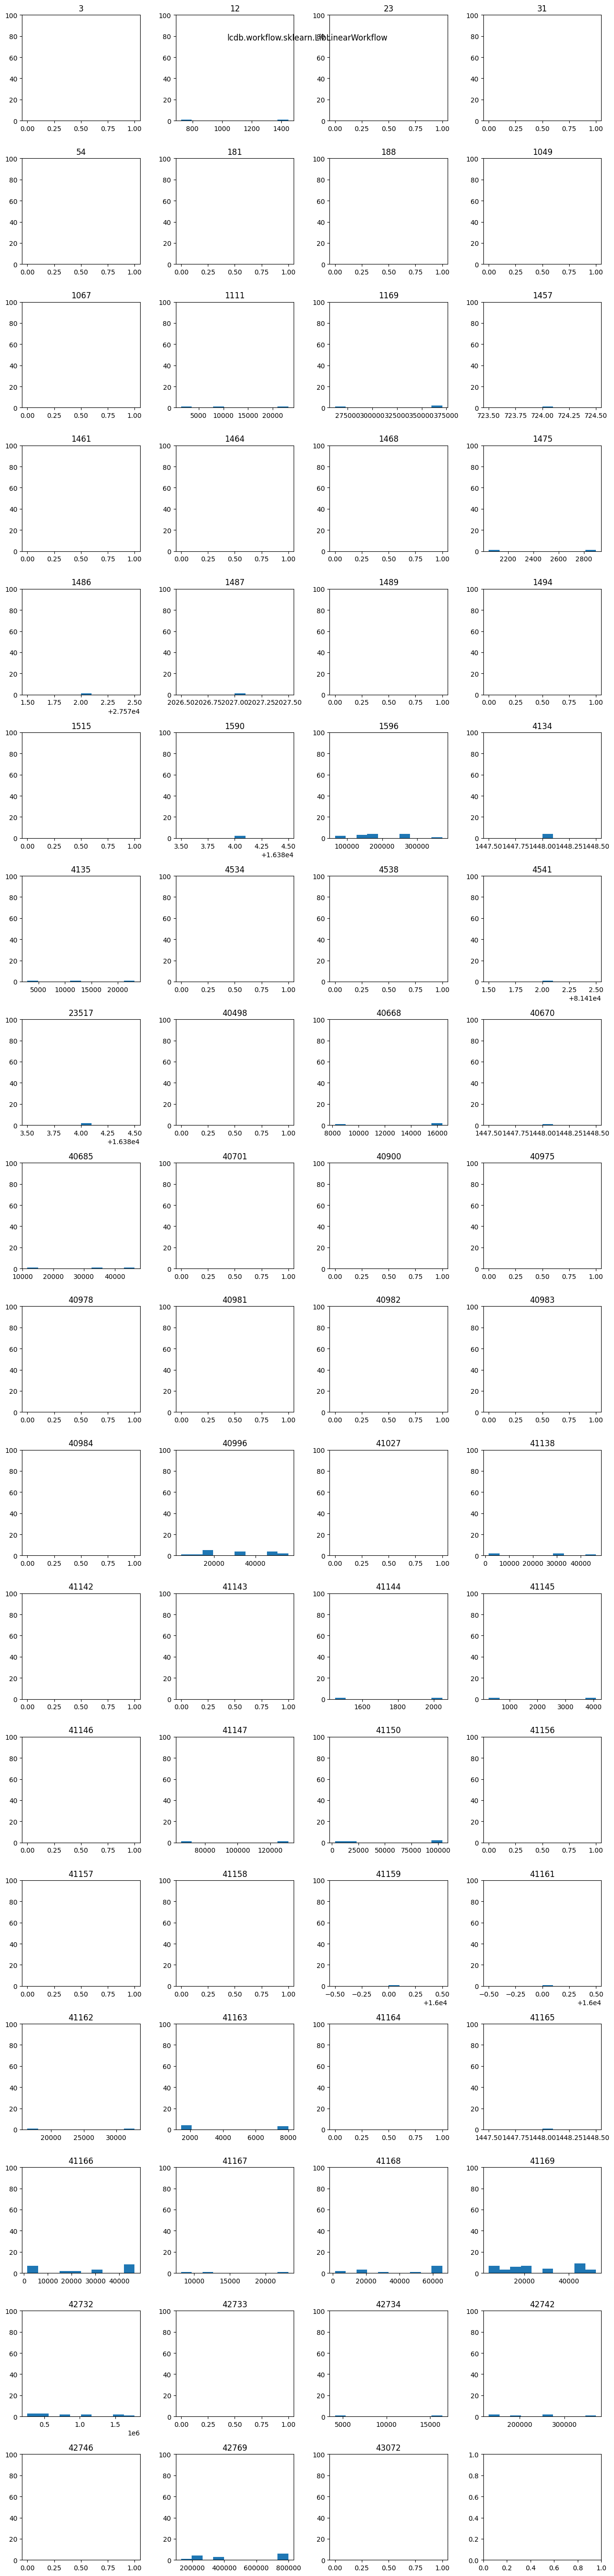

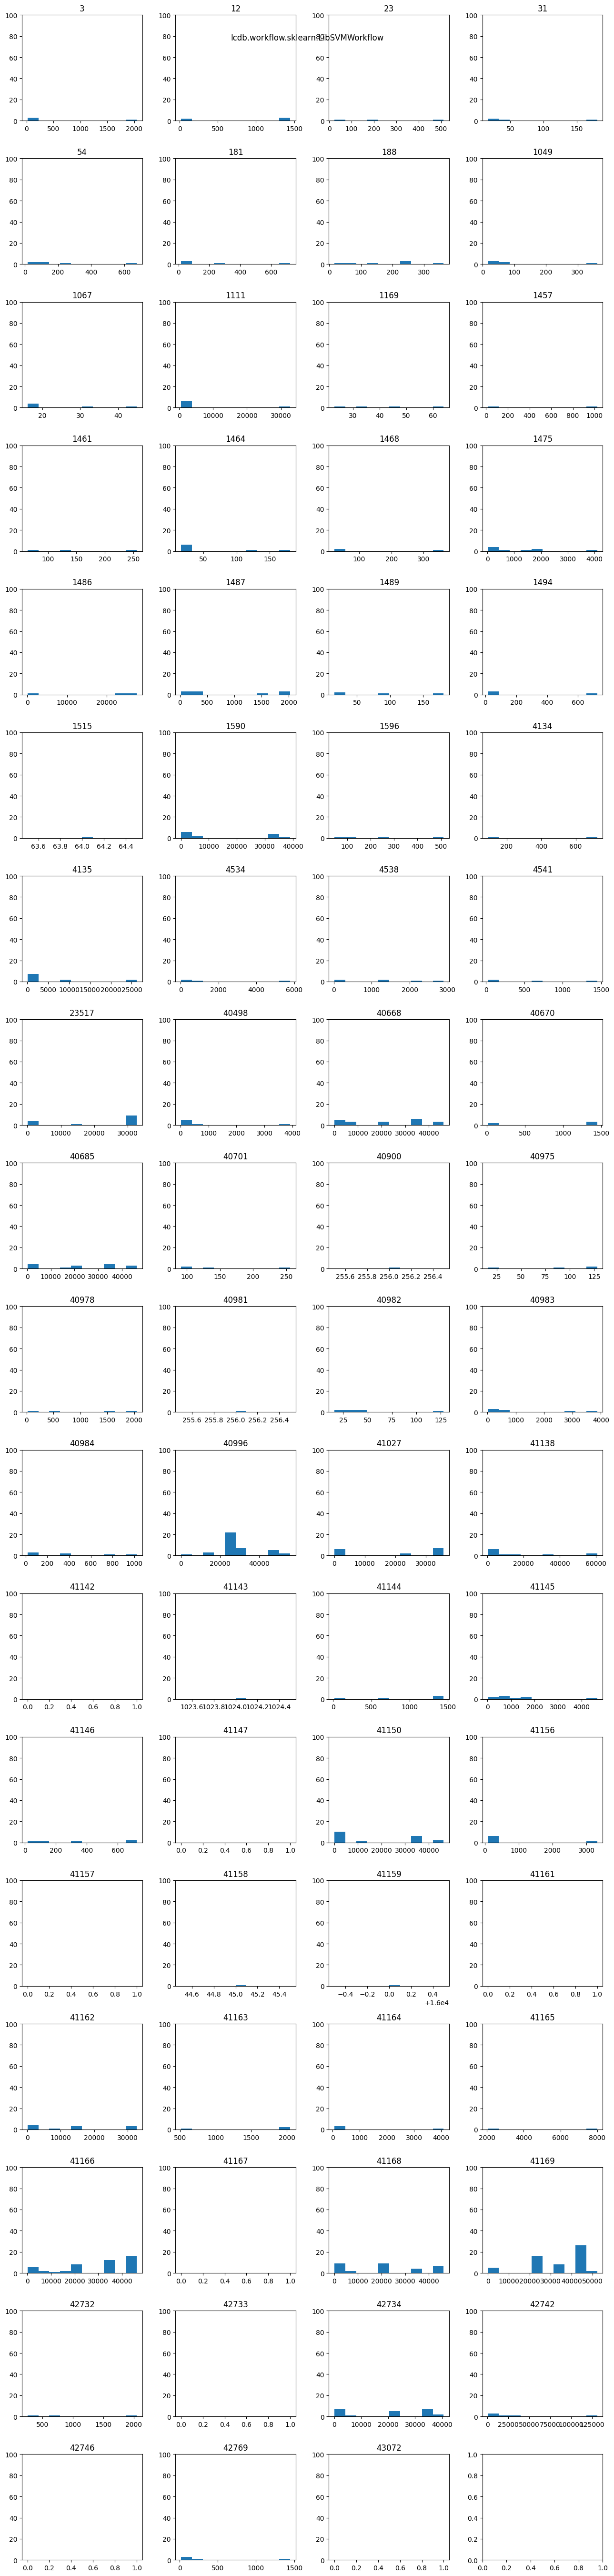

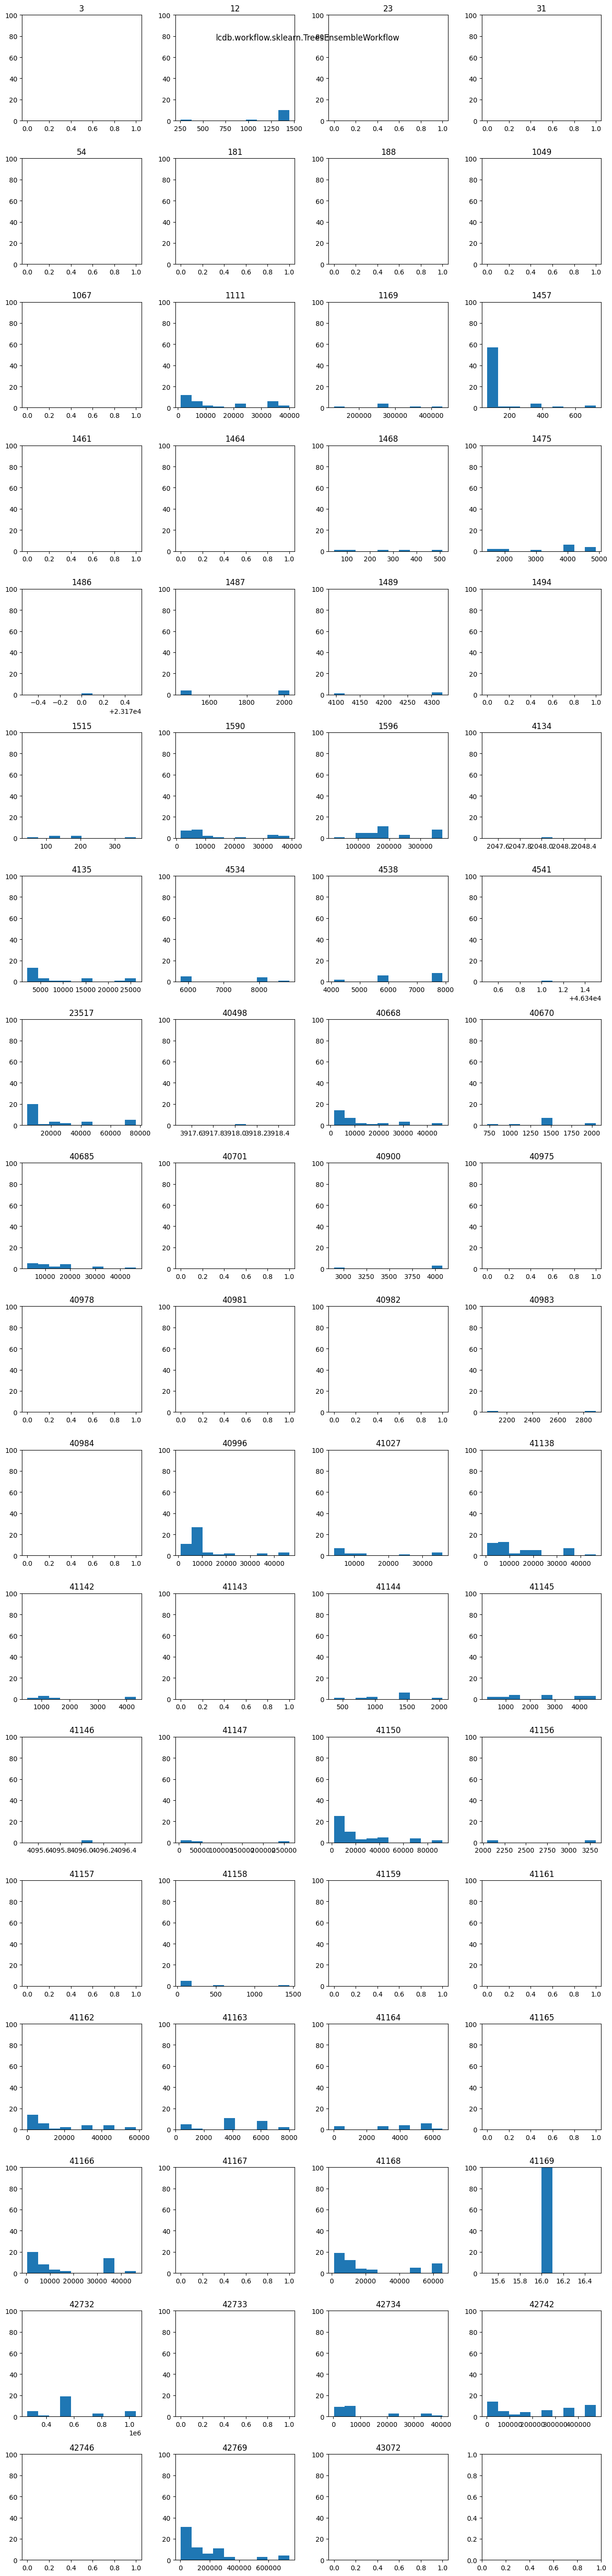

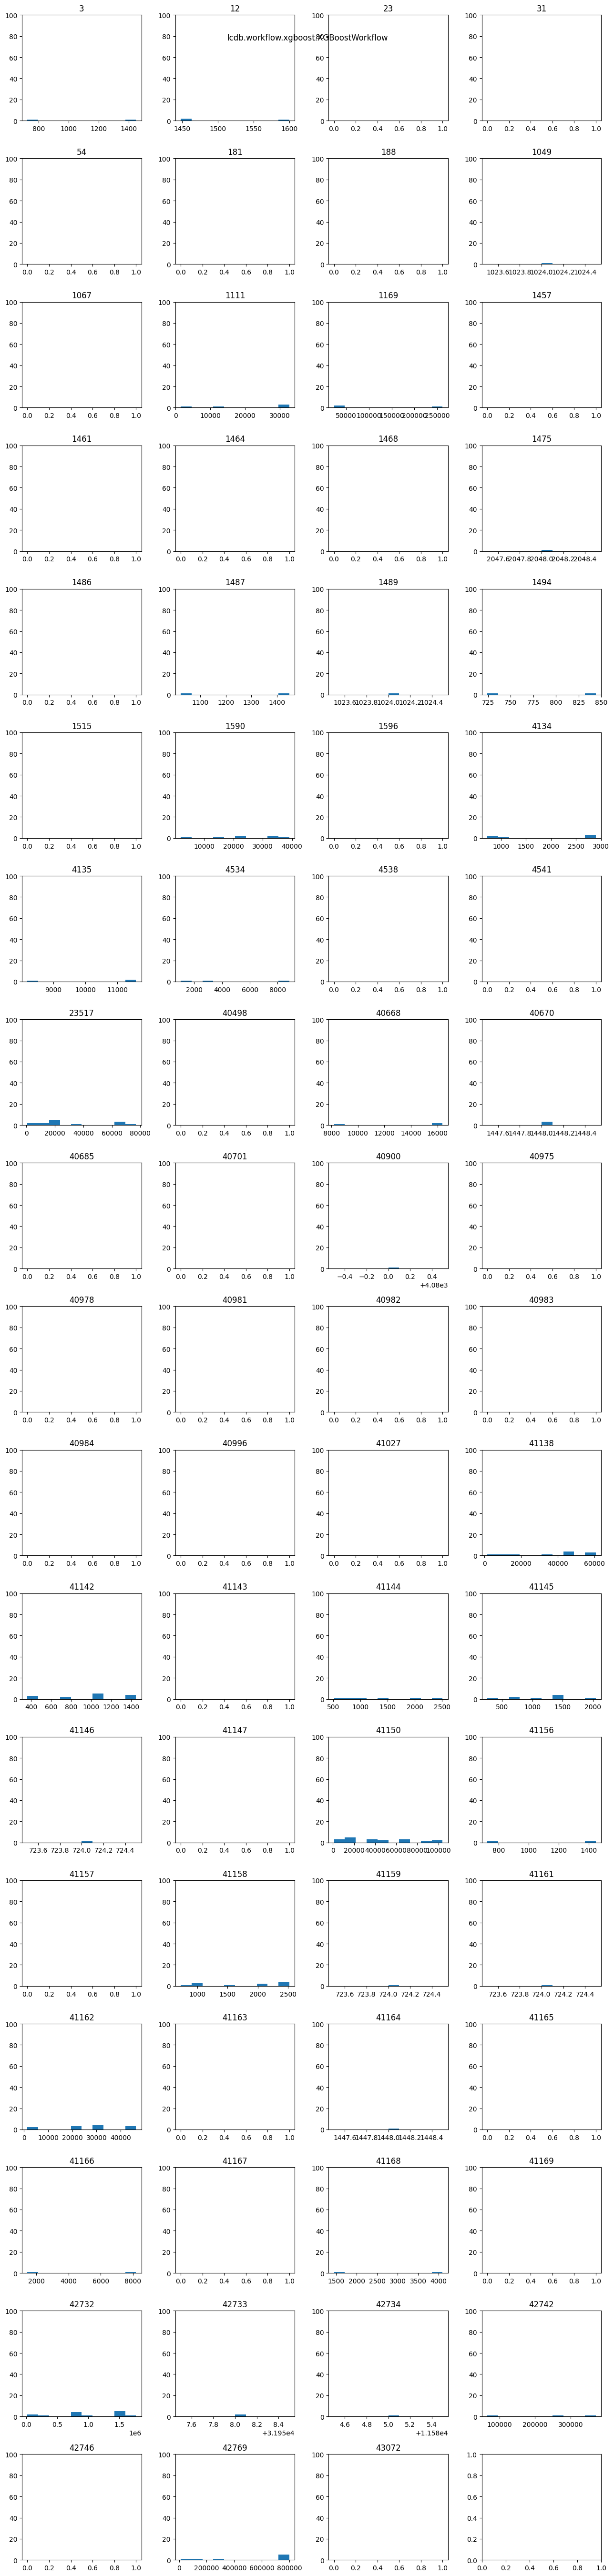

In [26]:
n_cols = 4
n_rows = int(np.ceil(len(d_datasets) / n_cols))

num_timeouts = 0
num_failed_configs = 0
for i, workflow in enumerate(d_workflows):
    mask = (overview_debugger.df["m:workflow"] == workflow)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(1 + n_cols * 3, 0.5 + n_rows * 3))
    for j, (dataset, ax) in enumerate(zip(d_datasets, axs.flatten())):
        df = overview_debugger.df[(overview_debugger.df["m:openmlid"] == dataset) & mask]
        anchors = []
        num_failed_configs += len(df)
        for summary in df["traceback_summary"]:
            matching_indices = np.where(["timeout" in msg["message"] for msg in summary])[0]
            if len(matching_indices) > 0:
                anchor = summary[matching_indices[0]]["location"][7:]
                anchors.append(int(anchor))
                num_timeouts += 1
                #print(matching_indices[0])
                #print(summary[matching_indices[0][0]])
        ax.hist(anchors)
        ax.set_ylim([0, 100])
        ax.set_title(dataset)
        #print(workflow, dataset, anchors)
    fig.suptitle(workflow)
    fig.tight_layout()
    plt.show()

# Specific Debugging

In [ ]:
specific_debugger = Debugger()
specific_debugger.load_data(
    campaigns=["pre-config-100"],
    openmlids=[4541],
    workflows=["lcdb.workflow.sklearn.KNNWorkflow"],
    show_progress=True
)

In [ ]:
specific_debugger.get_cli_test_command()